In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)

Installing package into ‘/home/jupyter/packages’
(as ‘lib’ is unspecified)



[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'All_SDoH_data.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
All_SDoH_data  <- read_csv(name_of_file_in_bucket)

# Get the current column names
current_colnames <- colnames(All_SDoH_data)

# Replace 'age_today' with 'age'
new_colnames <- gsub("age_at_last_event", "age", current_colnames)

# Set the new column names to the DataFrame
colnames(All_SDoH_data) <- new_colnames

character(0)

Rows: 156753 Columns: 53
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (36): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
print(nrow(All_SDoH_data))
colnames(All_SDoH_data)

[1] 156753


[1] "person_id"             "date_of_birth"         "AIAN"                 
 [4] "Asian"                 "Black"                 "Mid"                  
 [7] "Multiple"              "PI"                    "White"                
[10] "His"                   "race_unknown"          "SexGender"            
[13] "age_today"             "where_born"            "military"             
[16] "healthcare"            "disabled"              "sexual_orientation"   
[19] "LGBTQIA"               "min_date"              "max_date"             
[22] "ehr_length"            "relative_health"       "record_depth"         
[25] "visit_frequency"       "age"                   "education"            
[28] "employment"            "income"                "home_own"             
[31] "number_living"         "health_literacy"       "housing_quality"      
[34] "housing_instability"   "food_insecurity"       "Walkability"          
[37] "loneliness"            "crime_saftey"          "npd_scale"            
[40] "nsd_scale"             "discrimination"        "health_discrim"       
[43] "social_cohesion"       "stress"                "social_support"       
[46] "spirituality"          "health_coverage"       "health_care_use"      
[49] "delayed_care"          "afford_care"           "worried_pay"          
[52] "respect"               "per_poverty_threshold"

In [4]:
# Add age squared term. 
All_SDoH_data$age2<-All_SDoH_data$age^2

# SES cohort

In [5]:
SES_cohort<-All_SDoH_data[complete.cases(All_SDoH_data[, c('education', 'per_poverty_threshold')]), ]
nrow(SES_cohort)

[1] 125295

In [6]:
library(tidyverse)
library(bigrquery)

# This query represents dataset "area_ses" for domain "zip_code_socioeconomic" and was generated for All of Us Controlled Tier Dataset v8
dataset_75137822_zip_code_socioeconomic_sql <- paste("
    SELECT
        observation.person_id,
        observation.observation_datetime,
        zip_code.zip3_as_string as zip_code,
        zip_code.fraction_assisted_income as assisted_income,
        zip_code.fraction_high_school_edu as high_school_education,
        zip_code.median_income,
        zip_code.fraction_no_health_ins as no_health_insurance,
        zip_code.fraction_poverty as poverty,
        zip_code.fraction_vacant_housing as vacant_housing,
        zip_code.deprivation_index,
        zip_code.acs as american_community_survey_year 
    FROM
        `zip3_ses_map` zip_code 
    JOIN
        `observation` observation 
            ON CAST(SUBSTR(observation.value_as_string, 0, STRPOS(observation.value_as_string, '*') - 1) AS INT64) = zip_code.zip3 
            AND observation_source_concept_id = 1585250 
            AND observation.value_as_string NOT LIKE 'Res%'", sep="")

# Formulate a Cloud Storage destination path for the data exported from BigQuery.
# NOTE: By default data exported multiple times on the same day will overwrite older copies.
#       But data exported on a different days will write to a new location so that historical
#       copies can be kept as the dataset definition is changed.
zip_code_socioeconomic_75137822_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"),
  "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),  # Comment out this line if you want the export to always overwrite.
  "zip_code_socioeconomic_75137822",
  "zip_code_socioeconomic_75137822_*.csv")
message(str_glue('The data will be written to {zip_code_socioeconomic_75137822_path}. Use this path when reading ',
                 'the data into your notebooks in the future.'))

# Perform the query and export the dataset to Cloud Storage as CSV files.
# NOTE: You only need to run `bq_table_save` once. After that, you can
#       just read data from the CSVs in Cloud Storage.
bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), dataset_75137822_zip_code_socioeconomic_sql, billing = Sys.getenv("GOOGLE_PROJECT")),
  zip_code_socioeconomic_75137822_path,
  destination_format = "CSV")


# Read the data directly from Cloud Storage into memory.
# NOTE: Alternatively you can `gsutil -m cp {zip_code_socioeconomic_75137822_path}` to copy these files
#       to the Jupyter disk.
read_bq_export_from_workspace_bucket <- function(export_path) {
  col_types <- cols(zip3_as_string = col_character())
  bind_rows(
    map(system2('gsutil', args = c('ls', export_path), stdout = TRUE, stderr = TRUE),
        function(csv) {
          message(str_glue('Loading {csv}.'))
          chunk <- read_csv(pipe(str_glue('gsutil cat {csv}')), col_types = col_types, show_col_types = FALSE)
          if (is.null(col_types)) {
            col_types <- spec(chunk)
          }
          chunk
        }))
}
zip_code_socioeconomic_df <- read_bq_export_from_workspace_bucket(zip_code_socioeconomic_75137822_path)

dim(zip_code_socioeconomic_df)


area_data  <- zip_code_socioeconomic_df |> select('person_id', 'assisted_income', 'high_school_education',
'median_income','no_health_insurance','poverty','vacant_housing','deprivation_index')


The data will be written to gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20260413/zip_code_socioeconomic_75137822/zip_code_socioeconomic_75137822_*.csv. Use this path when reading the data into your notebooks in the future.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20260413/zip_code_socioeconomic_75137822/zip_code_socioeconomic_75137822_000000000000.csv.

Warning message:
“The following named parsers don't match the column names: zip3_as_string”


[1] 606414     11

In [7]:
area_data$no_high_school_education <- 100 - area_data$high_school_education
area_data$lower_median_income <- 
  max(area_data$median_income, na.rm = TRUE) - area_data$median_income

In [8]:
cols_to_scale <- c(
  "assisted_income",
  "high_school_education",
  "median_income",
  "no_health_insurance",
  "poverty",
  "vacant_housing",
  "deprivation_index",
  "no_high_school_education",
  "lower_median_income"
)

area_data[cols_to_scale] <- scale(area_data[cols_to_scale])

In [9]:
SES_cohort<-merge(SES_cohort, area_data, on="person_id")

SES_cohort$age2<-SES_cohort$age^2

In [10]:
nrow(SES_cohort)

[1] 125295

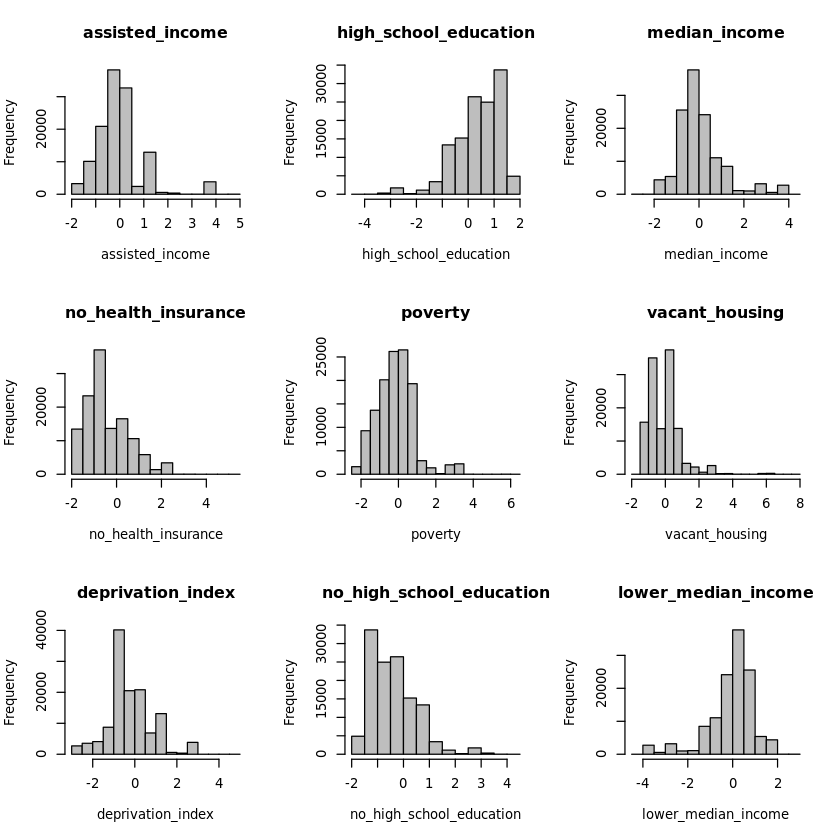

In [11]:
par(mfrow = c(3, 3))  # adjust layout

for (col in cols_to_scale) {
  hist(SES_cohort[[col]],
       main = col,
       xlab = col,
       col = "grey")
}

In [15]:
cor(SES_cohort[cols_to_scale])

,assisted_income,high_school_education,median_income,no_health_insurance,poverty,vacant_housing,deprivation_index,no_high_school_education,lower_median_income
assisted_income,1.0000000,-0.7788101,-0.6593226,0.5027970,0.8637914,0.4211679,0.9000800,0.7788101,0.6593226
high_school_education,-0.7788101,1.0000000,0.4573417,-0.6454915,-0.6885890,-0.2511032,-0.8201493,-1.0000000,-0.4573417
median_income,-0.6593226,0.4573417,1.0000000,-0.4900379,-0.7208954,-0.5042824,-0.8160091,-0.4573417,-1.0000000
no_health_insurance,0.5027970,-0.6454915,-0.4900379,1.0000000,0.5536230,0.3929145,0.7501025,0.6454915,0.4900379
poverty,0.8637914,-0.6885890,-0.7208954,0.5536230,1.0000000,0.4468780,0.9079966,0.6885890,0.7208954
vacant_housing,0.4211679,-0.2511032,-0.5042824,0.3929145,0.4468780,1.0000000,0.5474045,0.2511032,0.5042824
deprivation_index,0.9000800,-0.8201493,-0.8160091,0.7501025,0.9079966,0.5474045,1.0000000,0.8201493,0.8160091
no_high_school_education,0.7788101,-1.0000000,-0.4573417,0.6454915,0.6885890,0.2511032,0.8201493,1.0000000,0.4573417
lower_median_income,0.6593226,-0.4573417,-1.0000000,0.4900379,0.7208954,0.5042824,0.8160091,0.4573417,1.0000000


In [32]:
# This snippet assumes that you run setup first

# This code saves your dataframe into a csv file in a "data" folder in Google Bucket

# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe <- SES_cohort

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'SES_cohort.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

# Check if file is in the bucket
system(paste0("gsutil ls ", my_bucket, "/data/*.csv"), intern=T)

character(0)

[1] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/All_SDoH_data.csv"                                     
  [2] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/All_SDoH_data_domain_filtered_60.csv"                  
  [3] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Area_level_disease_statistics.csv"                     
  [4] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_Control_df.csv"                                   
  [5] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_control_demographics_SDOH_cohort.csv"             
  [6] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_control_demographics_SES_cohort.csv"              
  [7] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Demographic_and_ancestry_covariates.csv"               
  [8] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_Afib.csv"                 
  [9] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_Asthma.csv"               
 [10] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_BreastC.csv"              
 [11] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_CHD.csv"                  
 [12] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_CKD.csv"                  
 [13] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_HyperC.csv"               
 [14] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_ProstateC.csv"            
 [15] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_t1d.csv"                  
 [16] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_t2d.csv"                  
 [17] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_Afib.csv"                
 [18] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_Asthma.csv"              
 [19] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_BreastC.csv"             
 [20] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_CHD.csv"                 
 [21] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_CKD.csv"                 
 [22] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_HyperC.csv"              
 [23] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_ProstateC.csv"           
 [24] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_t1d.csv"                 
 [25] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_t2d.csv"                 
 [26] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_Afib.csv"                
 [27] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_Asthma.csv"              
 [28] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_BreastC.csv"             
 [29] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_CHD.csv"                 
 [30] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_CKD.csv"                 
 [31] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_HyperC.csv"              
 [32] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_ProstateC.csv"           
 [33] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_t1d.csv"                 
 [34] "gs://fc-secure-672eeb92-4859-4ed9-9